<a href="https://colab.research.google.com/github/vvelvadapu9/DemoAIProj/blob/Dev/DL_MODEL_Classification_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning Model Building From Scratch Using Tensorflow/Keras**

In [1]:
# Importing Data Set
import tensorflow as tf
from keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


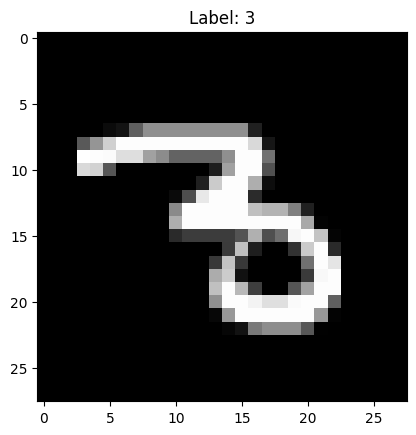

In [3]:
import matplotlib.pyplot as plt

plt.imshow(x_train[30],cmap="gray")
plt.title(f"Label: {y_train[30]}")
plt.show()

In [4]:
print(type(y_train))

<class 'numpy.ndarray'>


In [5]:
print(y_train)

[5 0 4 ... 5 6 8]


In [6]:
import pandas as pd
y_train_1=pd.DataFrame(y_train)
y_train_1.value_counts()

,count
0,
1,6742
7,6265
3,6131
2,5958
9,5949
0,5923
6,5918
8,5851
4,5842


In [7]:
type(x_train)

numpy.ndarray

In [8]:
type(x_train[0])

numpy.ndarray

In [9]:
# Let us apply normalization
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train=x_train/255
x_test=x_test/255
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [10]:
# Let us reshape x_train and x_test
x_train = x_train.reshape(60000, 28*28)
x_test = x_test.reshape(10000, 28*28)
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [11]:
# Let us build sequential Model
from keras.models import Sequential
from keras.layers import Dense

# Define Sequential Model
model=Sequential()

# Let us add input Layer
model.add(Dense(units=784, activation='relu', input_dim=28*28))

# Let us add Hidden Layer
model.add(Dense(units=10, activation='relu'))

# Let us add second hidden layer
model.add(Dense(units=10, activation='relu'))

# Let us add output layer
model.add(Dense(units=10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,510 (2.38 MB)

 Trainable params: 623,510 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Let us compile the model
model.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# ADAM

In [13]:
# Let us fit the model
history = model.fit(x_train, y_train, epochs=15, validation_split=0.2)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4810 - loss: 1.5338 - val_accuracy: 0.8754 - val_loss: 0.4183
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8888 - loss: 0.3924 - val_accuracy: 0.9218 - val_loss: 0.2744
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9213 - loss: 0.2718 - val_accuracy: 0.9405 - val_loss: 0.2097
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9381 - loss: 0.2178 - val_accuracy: 0.9457 - val_loss: 0.1820
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9523 - loss: 0.1683 - val_accuracy: 0.9565 - val_loss: 0.1540
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9598 - loss: 0.1412 - val_accuracy: 0.9567 - val_loss: 0.1463
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9658 - loss: 0.1193 - val_accuracy: 0.9617 - val_loss: 0.1326
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9704 - loss: 0.1043 - 

In [14]:
# Let us make predictions
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9627 - loss: 0.1213


[0.10763675719499588, 0.9667999744415283]

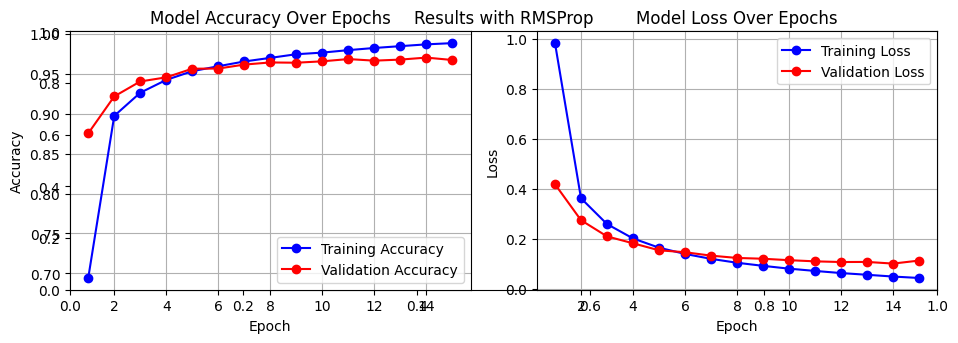

In [15]:
import matplotlib.pyplot as plt

# Extract metrics from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.title("Results with RMSProp")
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()